In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv("C:\\Users\\NITIN GOSWAMI\\.vscode\\Customer Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
# Replaced Blanks with 0 as tenure is 0 and no total charges are recorded

df["TotalCharges"] = df["TotalCharges"].replace(" ","0")
df["TotalCharges"] = df["TotalCharges"].astype("float")

In [ ]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [9]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [6]:
df.duplicated().sum()

np.int64(0)

In [12]:
df["customerID"].duplicated().sum()

np.int64(0)

In [ ]:
# Converted 0 and 1 values of senior citizen to Yes/No to make it easier to understand 

def conv(value):
    if value == 1:
        return "Yes"
    else:
        return "No"
df["SeniorCitizen"] = df["SeniorCitizen"].apply(conv)

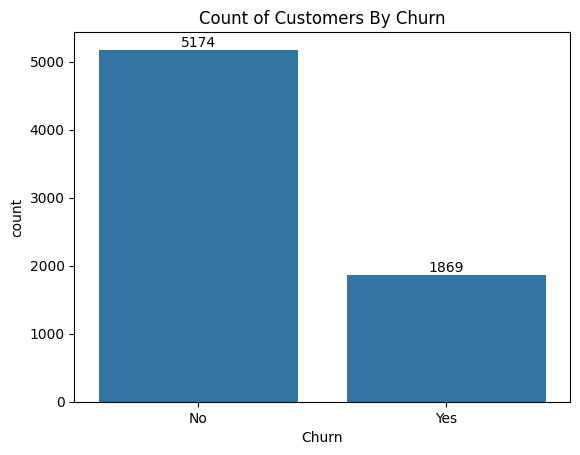

In [ ]:
# Overall Churn Rate

ax = sns.countplot(x = "Churn", data = df)
ax.bar_label(ax.containers[0])
plt.title("Count of Customers By Churn")
plt.show()

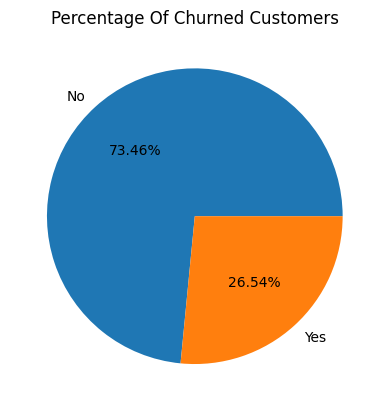

In [21]:
gb = df.groupby("Churn").agg({'Churn':"count"})
plt.pie(gb["Churn"], labels = gb.index, autopct= "%1.2f%%")
plt.title("Percentage Of Churned Customers")
plt.show()

In [ ]:
# From the given pie chart we can conclude that 26.54% of our customers have churned out.
# Now lets explore the reason behind it. 

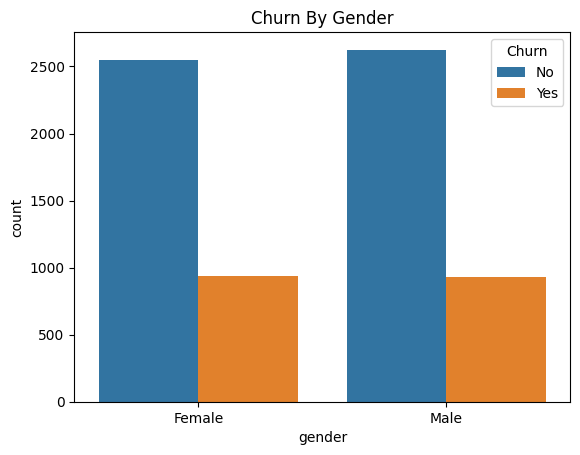

In [22]:
sns.countplot(x="gender", data=df, hue="Churn")
plt.title("Churn By Gender")
plt.show()

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


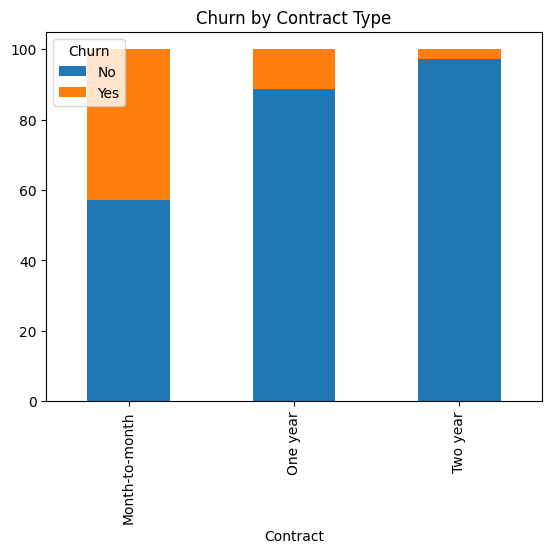

In [ ]:
# Churn by Contract Type
 
contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
print(contract_churn)

contract_churn.plot(kind='bar', stacked=True)
plt.title("Churn by Contract Type")
plt.show()

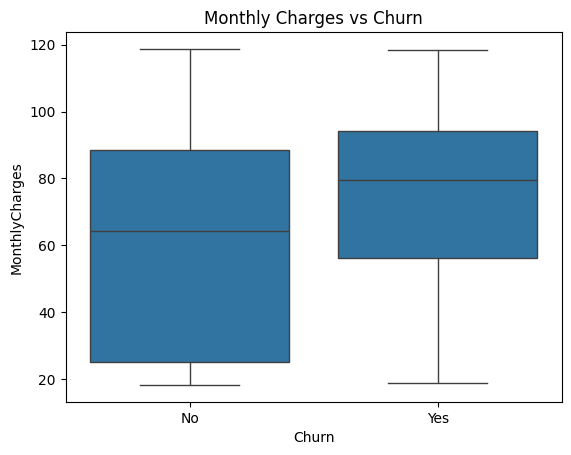

In [ ]:
# Monthly Charges vs Churn

sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

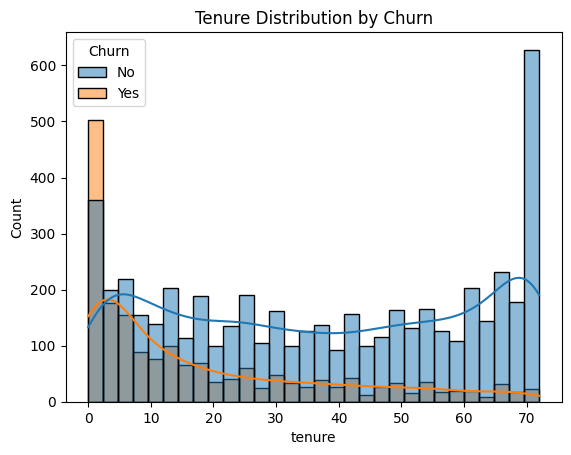

In [ ]:
# Tenure VS Churn

sns.histplot(data=df, x='tenure', hue='Churn', bins=30, kde=True)
plt.title("Tenure Distribution by Churn")
plt.show()

Churn                   No        Yes
InternetService                      
DSL              81.040892  18.959108
Fiber optic      58.107235  41.892765
No               92.595020   7.404980


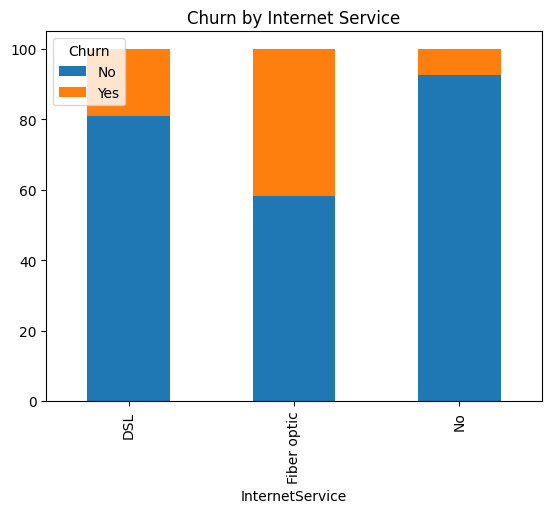

In [ ]:
# Internet Service Impact 

internet_churn = pd.crosstab(df['InternetService'], df['Churn'], normalize='index') * 100
print(internet_churn)

internet_churn.plot(kind='bar', stacked=True)
plt.title("Churn by Internet Service")
plt.show()


TechSupport
 Churn                       No        Yes
TechSupport                              
No                   58.364526  41.635474
No internet service  92.595020   7.404980
Yes                  84.833659  15.166341


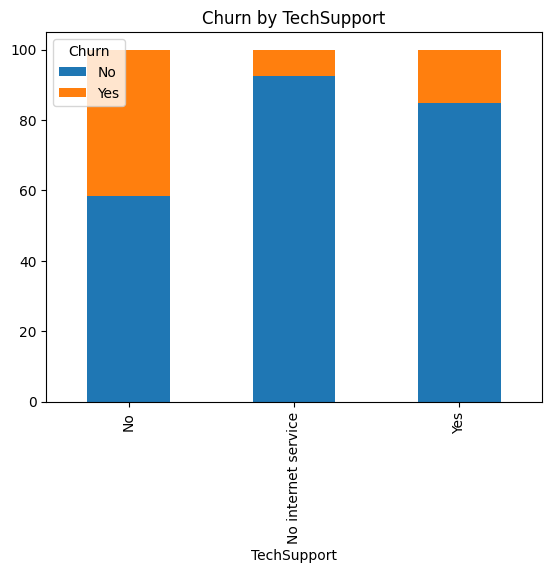


OnlineSecurity
 Churn                       No        Yes
OnlineSecurity                           
No                   58.233276  41.766724
No internet service  92.595020   7.404980
Yes                  85.388806  14.611194


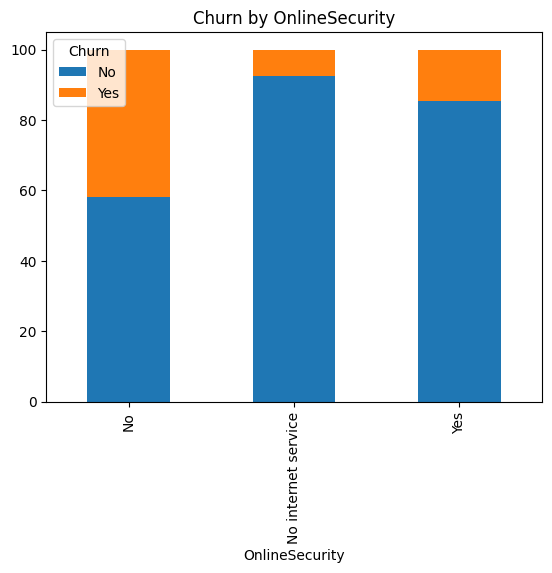

In [ ]:
# Tech Support & Online Security

features = ['TechSupport', 'OnlineSecurity']

for col in features:
    table = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
    print(f"\n{col}\n", table)
    
    table.plot(kind='bar', stacked=True)
    plt.title(f"Churn by {col}")
    plt.show()

Churn                             No        Yes
PaymentMethod                                  
Bank transfer (automatic)  83.290155  16.709845
Credit card (automatic)    84.756899  15.243101
Electronic check           54.714588  45.285412
Mailed check               80.893300  19.106700


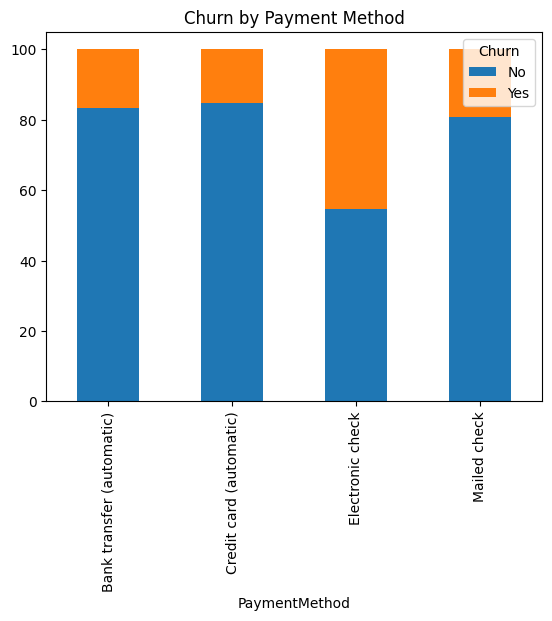

In [ ]:
# Payment Method Analysis

payment_churn = pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index') * 100
print(payment_churn)

payment_churn.plot(kind='bar', stacked=True)
plt.title("Churn by Payment Method")
plt.show()

In [ ]:
# Gender Impact 

pd.crosstab(df['gender'], df['Churn'], normalize='index') * 100

Churn,No,Yes
gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338


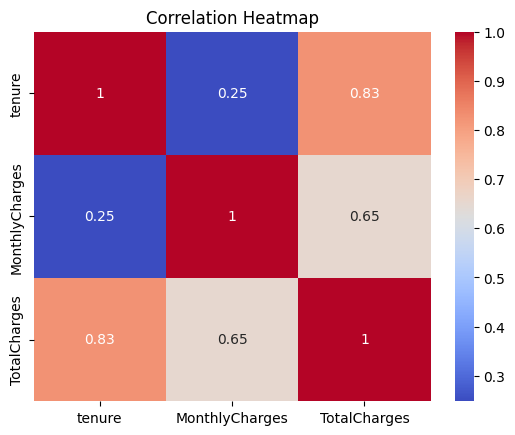

In [ ]:
# Correlation Heatmap

num_df = df.select_dtypes(include=['int64', 'float64'])

sns.heatmap(num_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [19]:
print("Key Insights:")
print("""
1. High churn in month-to-month contracts
2. New customers (low tenure) are at highest risk
3. Higher monthly charges increase churn probability
4. Fiber optic users show higher churn
5. Lack of tech support/security leads to churn
6. Electronic check users are more likely to leave
""")

Key Insights:

1. High churn in month-to-month contracts
2. New customers (low tenure) are at highest risk
3. Higher monthly charges increase churn probability
4. Fiber optic users show higher churn
5. Lack of tech support/security leads to churn
6. Electronic check users are more likely to leave

